# BHSD

* Contents

1. Patient Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> 1.4 Patient
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    <br> 2.3 Windowing
    3. Slice level Class
    4. Visualization
    
2. Dataset Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    3. Class
    <br> 3.1 Number of Bleed
    <br> 3.2 Type of Bleed
    <br> 3.3 Volume of Bleed
    4. Visualization

3. nnUNet Dataset 구성
<br> class imbalance 고려

* Dataset Structure
    - `label_192`는 image와 ground mask가 같이 있는 labeled set
    - `unlabel_1980`는 segmentation mask가 없는 unlabeled set
    <br> 내부에 anybleed / nobleed가 있어 `case-level` 구분은 존재함


* Mask Semantics
    - `ground truths`는 class별 파일 분리가 아니라, 
    <br>한 volume 안에서 voxel value로 class를 구분함
    - class ids는 `0~5`
    - 0은 background, 나머지는 ICH subtype

* What to Watch
    - class imbalance가 큼
    - volume spacing과 slice count가 case마다 다를 수 있음
    - CT intensity는 raw range를 먼저 보고 windowing 여부를 결정하는 게 안전함
    - overlay로 mask alignment를 꼭 확인할 것


---

In [1]:
import os
from pathlib import Path
from collections import Counter

from scipy import ndimage
import numpy as np
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## 1. Patient Unit Analysis

### 1. Basic Info

#### 1.1 path

In [2]:
# dataset, image, mask
DATA_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data")
DATASET_ROOT = DATA_ROOT / "bhsd" / "label_192"

IMAGE_ROOT = DATASET_ROOT / "images"
MASK_ROOT = DATASET_ROOT / "ground truths"

#### 1.2 Class Mapping 

In [ ]:
class_map = {
    0: 'background',
    1: 'epidural',
    2: 'intraparenchymal',
    3: 'intraventricular',
    4: 'subarachnoid',
    5: 'subdural',
}

class_names = {
    1: 'EDH', 
    2: 'IPH', 
    3: 'IVH', 
    4: 'SAH', 
    5: 'SDH'
}

class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

class_names_1cls = {
    0: 'background',
    1: 'ich',
}

class_colors_1cls = {
    0: (0, 0, 0),
    1: (0, 255, 255),
}


#### 1.3 Dataset

In [5]:
# 확장자 파일 가져와서 이름순 정렬 리스트
image_path = sorted(IMAGE_ROOT.glob("*.nii.gz"))
mask_path = sorted(MASK_ROOT.glob("*.nii.gz"))

image_map = {p.name: p for p in image_path}
mask_map = {p.name: p for p in mask_path}
common_keys = sorted(set(image_map) & set(mask_map))

In [35]:
print(common_keys)

['ID_0237f3c9_ID_40015688b9.nii.gz', 'ID_029ebbea_ID_563afa0901.nii.gz', 'ID_02b882cc_ID_a4892e60ae.nii.gz', 'ID_02f779fb_ID_c4d7f33559.nii.gz', 'ID_041e6601_ID_1fa1d20bba.nii.gz', 'ID_0492041f_ID_b4fcf2f799.nii.gz', 'ID_05331dc6_ID_47213b7e2e.nii.gz', 'ID_07365cde_ID_8e661b8f07.nii.gz', 'ID_089596a9_ID_ea71b57820.nii.gz', 'ID_09b33fc4_ID_bcd322d4ed.nii.gz', 'ID_0b10cbee_ID_f91d6a7cd2.nii.gz', 'ID_0c3eef60_ID_6994ad7df0.nii.gz', 'ID_0c6b97a9_ID_6011bb9ce8.nii.gz', 'ID_10beb45f_ID_7184e80f09.nii.gz', 'ID_10c64d22_ID_4c9aad31ca.nii.gz', 'ID_14058625_ID_527c581583.nii.gz', 'ID_1653b22b_ID_c35cd0de73.nii.gz', 'ID_16ed917a_ID_145f184354.nii.gz', 'ID_181aab15_ID_062634d043.nii.gz', 'ID_18747540_ID_1eb1de9633.nii.gz', 'ID_1879071b_ID_4b8e1377e7.nii.gz', 'ID_196704db_ID_4eb6296376.nii.gz', 'ID_199b0a56_ID_09e623e993.nii.gz', 'ID_19d26713_ID_9f54cdc920.nii.gz', 'ID_1cbe2853_ID_37afefdc7c.nii.gz', 'ID_2334b45f_ID_9f31e831ac.nii.gz', 'ID_253e809f_ID_095d8c391f.nii.gz', 'ID_268b38fe_ID_d747ae3ffb.

In [9]:
print("전체 이미지 개수:", len(image_path))
print("전체 마스크 개수:", len(mask_path))
print("Matched Pair:", len(common_keys))
print("Image Only:", len(set(image_map) - set(mask_map)))
print("Mask Only:", len(set(mask_map) - set(image_map)))

전체 이미지 개수: 192
전체 마스크 개수: 192
Matched Pair: 192
Image Only: 0
Mask Only: 0


#### 1.4 Patient

In [10]:
# patient 1
patient_key = common_keys[0]
print("선택 환자:", patient_key) #확장자를 제거하려면? 

선택 환자: ID_0237f3c9_ID_40015688b9.nii.gz


In [11]:
# SimpleTK.Image
# 3차원 의료영상 객체 
img_sitk = sitk.ReadImage(str(image_map[patient_key]))
mask_sitk = sitk.ReadImage(str(mask_map[patient_key]))

# Numpy Array 
img_arr = sitk.GetArrayFromImage(img_sitk)
mask_arr = sitk.GetArrayFromImage(mask_sitk)

In [124]:
num_slices = 15
print("슬라이스 배열 개수:", len(img_arr))
print("15번 슬라이스 배열:\n", img_arr[num_slices])
print("15번 슬라이스 배열 크기:", img_arr[num_slices].shape)
print("\n")
print("15번 슬라이스 마스크:\n", mask_arr[num_slices])

슬라이스 배열 개수: 28
15번 슬라이스 배열:
 [[-2048. -2048. -2048. ... -2048. -2048. -2048.]
 [-2048. -2048. -2048. ... -2048. -2048. -2048.]
 [-2048. -2048. -2048. ... -2048. -2048. -2048.]
 ...
 [-2048. -2048. -2048. ... -2048. -2048. -2048.]
 [-2048. -2048. -2048. ... -2048. -2048. -2048.]
 [-2048. -2048. -2048. ... -2048. -2048. -2048.]]
15번 슬라이스 배열 크기: (512, 512)


15번 슬라이스 마스크:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [125]:
# 병변이 있는 배열 쪽 확대한 배열 + 같이 시각화 
target_slice_img = img_arr[num_slices]
target_slice_mask = mask_arr[num_slices]

# 병변이 있는 좌표 찾기 -> bounding box
ys, xs = np.where(target_slice_mask > 0)

if len(xs) == 0:
    print(f"{num_slices}번 슬라이스에는 병변이 없습니다.")
else:
    margin = 10  # 여백
    y0, y1 = max(ys.min() - margin, 0), min(ys.max() + margin, target_slice_mask.shape[0])
    x0, x1 = max(xs.min() - margin, 0), min(xs.max() + margin, target_slice_mask.shape[1])

    cropped_img = target_slice_img[y0:y1, x0:x1]
    cropped_mask = target_slice_mask[y0:y1, x0:x1]

    print("crop 영역 (y0:y1, x0:x1):", (y0, y1, x0, x1))
    print("crop된 이미지 배열:\n", cropped_img)
    print("\ncrop된 마스크 배열:\n", cropped_mask)

crop 영역 (y0:y1, x0:x1): (np.int64(137), np.int64(259), np.int64(241), np.int64(321))
crop된 이미지 배열:
 [[33. 28. 31. ... 31. 34. 34.]
 [33. 30. 31. ... 36. 36. 36.]
 [37. 35. 35. ... 38. 35. 31.]
 ...
 [12. 18. 24. ... 44. 43. 41.]
 [ 7. 13. 22. ... 42. 43. 44.]
 [ 6. 13. 22. ... 40. 41. 40.]]

crop된 마스크 배열:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [126]:
print(img_sitk)

Image (0x5a3381b54160)
  RTTI typeinfo:   itk::Image<float, 3u>
  Reference Count: 1
  Modified Time: 4490
  Debug: Off
  Object Name: 
  Observers: 
    none
  Source: (none)
  Source output name: (none)
  Release Data: Off
  Data Released: False
  Global Release Data: Off
  PipelineMTime: 4464
  UpdateMTime: 4486
  RealTimeStamp: 0 seconds 
  LargestPossibleRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 28]
  BufferedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 28]
  RequestedRegion: 
    Dimension: 3
    Index: [0, 0, 0]
    Size: [512, 512, 28]
  Spacing: [0.488281, 0.488281, 5.288]
  Origin: [-125, 96.0279, -63.315]
  Direction: 
1 0 0
0 -0.945519 0.325568
0 0.325568 0.945519

  IndexToPointMatrix: 
0.488281 0 0
0 -0.461679 1.7216
0 0.158969 4.9999

  PointToIndexMatrix: 
2.048 0 0
0 -1.93642 0.666763
0 0.0615673 0.178805

  Inverse Direction: 
1 0 0
0 -0.945519 0.325568
0 0.325568 0.945519

  PixelContainer: 
    ImportImageContainer (0

In [ ]:
# 주요 정보 확인
print("이미지 정보")
print("크기:", img_sitk.GetSize())
print("타입:", img_sitk.GetPixelIDTypeAsString())
print("==="*15)
print("마스크 정보")
print("크기:", mask_sitk.GetSize())
print("타입:", mask_sitk.GetPixelIDTypeAsString())

# spacing, origin, direction
direction = np.array(img_sitk.GetDirection()).reshape(3, 3)
spacing = np.array(img_sitk.GetSpacing())
origin = np.array(img_sitk.GetOrigin())
affine = np.eye(4)

print("==="*15)
print("Spacing:", spacing)
print("Origin:\n", direction)
affine[:3, :3] = direction * spacing
affine[:3, 3] = origin
print("Affine:\n", affine)

orient_filter = sitk.DICOMOrientImageFilter()
print("Orientation:", 
orient_filter.GetOrientationFromDirectionCosines(img_sitk.GetDirection()))
# LAS: Left, Anterior, Superior

이미지 정보
크기: (512, 512, 28)
타입: 32-bit float
마스크 정보
크기: (512, 512, 28)
타입: 16-bit unsigned integer
Spacing: [0.48828101 0.48828101 5.28800011]
Origin:
 [[ 1.          0.          0.        ]
 [ 0.         -0.94551866  0.32556791]
 [ 0.          0.32556791  0.94551866]]
Affine:
 [[   0.48828101    0.            0.         -125.        ]
 [   0.           -0.46167881    1.72160317   96.02786255]
 [   0.            0.15896863    4.99990276  -63.31497192]
 [   0.            0.            0.            1.        ]]
Orientation: LAS


### 2. 3D CT

#### 2.1 Min/ Max

In [128]:
# min / max, percentiles
flat = img_arr.astype(np.float32).ravel()
percentiles = np.percentile(flat, [0, 0.5, 1, 5, 50, 95, 99, 99.5, 100])
print("min/max:", flat.min(), flat.max())
print("percentiles:", percentiles)

min/max: -2048.0 3071.0
percentiles: [-2048. -2048. -2048. -2048.  -988.   730.  1542.  1636.  3071.]


In [129]:
min_value = flat.min()
min_ratio = (flat == min_value).mean()
print(f"min값({min_value}) 비율: {min_ratio:.1%}")

min값(-2048.0) 비율: 21.3%


#### 2.2 HU

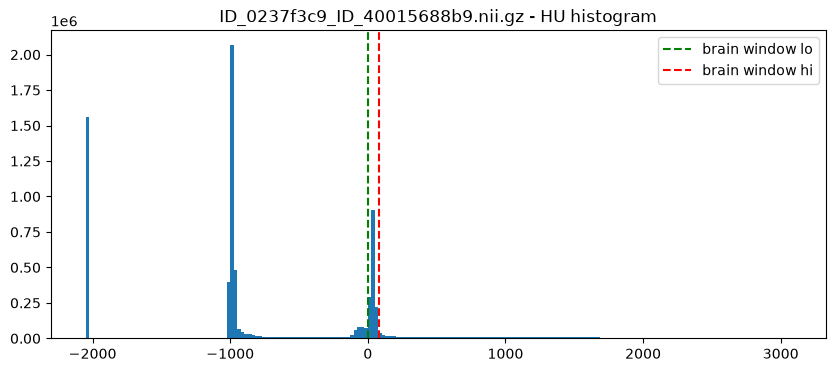

In [130]:
plt.figure(figsize=(10, 4))
plt.hist(flat, bins=200)
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.legend()
plt.title(f'{patient_key} - HU histogram')
plt.show()

#### 2.3 Windowing w/, w/o

In [49]:
# windowing 적용 함수
def apply_window(slice_hu, window_level=40, window_width=80):
    # HU 0 ~ 80 사이
    lo = window_level - window_width / 2 # HU 0
    hi = window_level + window_width / 2 # HU 80
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)

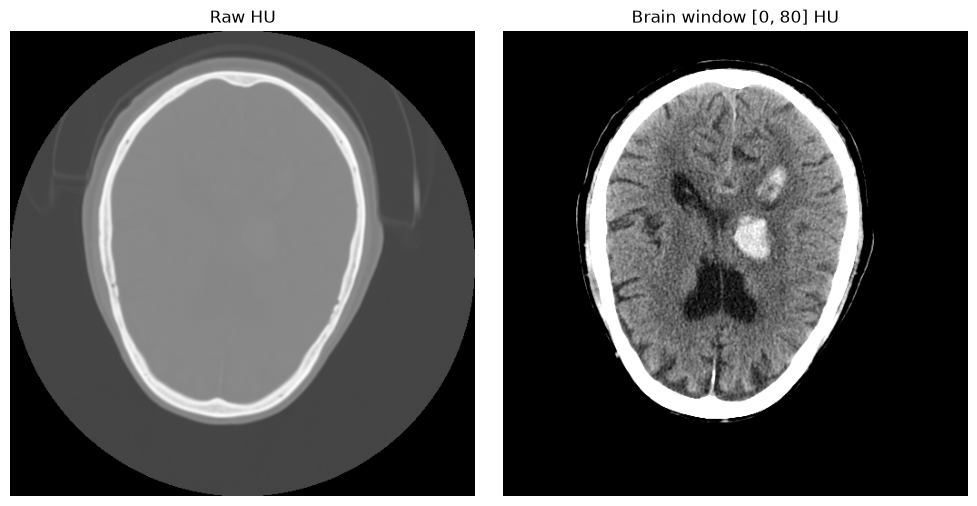

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr[num_slices], cmap='gray')
axes[0].set_title('Raw HU')
axes[0].axis('off')
axes[1].imshow(apply_window(img_arr[num_slices]), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Brain window [0, 80] HU')
axes[1].axis('off')
plt.tight_layout()

### 3. Class

Slice level + Voxel level 

In [133]:
# class
n_slices = len(img_arr)
rows = []

for z in range(n_slices):
    classes_in_slice = sorted(set(np.unique(mask_arr[z]).tolist()) - {0})
    rows.append({
        'slice': z,
        'n_classes': len(classes_in_slice),
        'classes': ', '.join([class_names[c] for c in classes_in_slice]),
        'fg_voxels': int((mask_arr[z] > 0).sum()), # 병변의 픽셀 개수 
    })

df_slices = pd.DataFrame(rows)
display(df_slices[df_slices['n_classes'] > 0])

,slice,n_classes,classes,fg_voxels
12,12,1,IPH,297
13,13,1,IPH,876
14,14,2,"IPH, IVH",1904
15,15,2,"IPH, IVH",2436
16,16,2,"IPH, IVH",2000
17,17,2,"IPH, IVH",1152
18,18,1,IPH,109


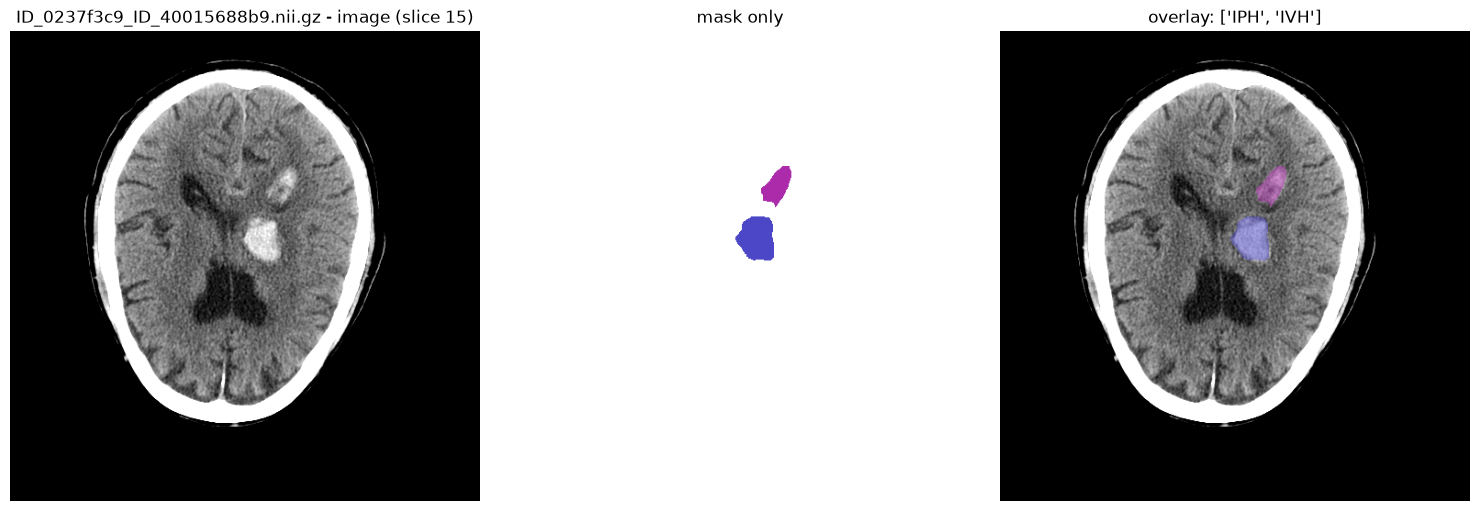

In [ ]:
best_z = int(df_slices['fg_voxels'].idxmax())
windowed_slice = apply_window(img_arr[best_z])
mask_slice = mask_arr[best_z]
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'{patient_key} - image (slice {best_z})')
axes[0].axis('off')


n_classes = max(class_colors.keys()) + 1   # 5 + 1 = 6 (0~5)
colors_rgb = np.zeros((n_classes, 3))
for cls, rgb in class_colors.items():
    colors_rgb[cls] = np.array(rgb) / 255
custom_cmap = ListedColormap(colors_rgb)

mask_only_display = np.ma.masked_where(mask_slice == 0, mask_slice)

axes[1].set_facecolor('black')  # masked(배경) 영역이 이 색으로 보임 → "색 없음" 효과
axes[1].imshow(mask_only_display, cmap=custom_cmap, vmin=0, vmax=5)
axes[1].set_title('mask only')
axes[1].axis('off')

axes[2].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[2].imshow(mask_overlay, cmap=custom_cmap, alpha=0.5, vmin=0, vmax=5)
present = [class_names[c] for c in np.unique(mask_slice) if c != 0]
axes[2].set_title(f'overlay: {present}')
axes[2].axis('off')
plt.tight_layout()
plt.show()

### 4. Visualization

In [1]:
from ctviewer import CTViewer
CTViewer(img_arr)

NameError: name 'img_arr' is not defined

---

## 2. Dataset Unit Analysis

### 1. Basic Info

#### 1.1 Path

In [166]:
# dataset, image, mask
DATA_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/data")
DATASET_ROOT = DATA_ROOT / "bhsd" / "label_192"

IMAGE_ROOT = DATASET_ROOT / "images"
MASK_ROOT = DATASET_ROOT / "ground truths"

#### 1.2 Class Mapping 

In [ ]:
class_map = {
    0: 'background',
    1: 'epidural',
    2: 'intraparenchymal',
    3: 'intraventricular',
    4: 'subarachnoid',
    5: 'subdural',
}

class_names = {
    1: 'EDH', 
    2: 'IPH', 
    3: 'IVH', 
    4: 'SAH', 
    5: 'SDH'
}

class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

class_names_1cls = {
    0: 'background',
    1: 'ich',
}

class_colors_1cls = {
    0: (0, 0, 0),
    1: (255, 255, 0),
}

#### 1.3 Dataset

In [153]:
# 확장자 파일 가져와서 이름순 정렬 리스트
image_path = sorted(IMAGE_ROOT.glob("*.nii.gz"))
mask_path = sorted(MASK_ROOT.glob("*.nii.gz"))

image_map = {p.name: p for p in image_path}
mask_map = {p.name: p for p in mask_path}
common_keys = sorted(set(image_map) & set(mask_map))

In [154]:
print("전체 이미지 개수:", len(image_path))
print("전체 마스크 개수:", len(mask_path))
print("Matched Pair:", len(common_keys))
print("Image Only:", len(set(image_map) - set(mask_map)))
print("Mask Only:", len(set(mask_map) - set(image_map)))

전체 이미지 개수: 192
전체 마스크 개수: 192
Matched Pair: 192
Image Only: 0
Mask Only: 0


In [32]:
print(list(image_map.keys())[0].split('_'))

['ID', '0237f3c9', 'ID', '40015688b9.nii.gz']


In [ ]:
# 환자 겹침 확인
def patient_id(filename: str) -> str:
    # ID_{patientID}_ID_{studyID}.nii.gz -> patientID
    return filename.split('_')[1]

case_patient = pd.Series({k: patient_id(k) for k in common_keys})

In [34]:
print(case_patient)
print("전체 case 수:", len(case_patient))
print("고유 환자 수:", case_patient.nunique())

ID_0237f3c9_ID_40015688b9.nii.gz    0237f3c9
ID_029ebbea_ID_563afa0901.nii.gz    029ebbea
ID_02b882cc_ID_a4892e60ae.nii.gz    02b882cc
ID_02f779fb_ID_c4d7f33559.nii.gz    02f779fb
ID_041e6601_ID_1fa1d20bba.nii.gz    041e6601
                                      ...   
ID_f335b6db_ID_d180629430.nii.gz    f335b6db
ID_f4795940_ID_6317a06429.nii.gz    f4795940
ID_faa3c13d_ID_c31106b8dc.nii.gz    faa3c13d
ID_fb6d0135_ID_497840f16e.nii.gz    fb6d0135
ID_fcbe7eda_ID_5726e1c630.nii.gz    fcbe7eda
Length: 192, dtype: str
전체 case 수: 192
고유 환자 수: 191


In [13]:
overlap = case_patient.value_counts()
overlap = overlap[overlap > 1]
print("여러 case를 가진 환자 수:", len(overlap))

전체 case 수: 192
고유 환자 수: 191
여러 case를 가진 환자 수: 1


In [160]:
sitk.ProcessObject.SetGlobalWarningDisplay(False)
rows = []
orient_filter = sitk.DICOMOrientImageFilter()

for key in common_keys:
    v_img = sitk.ReadImage(str(image_map[key]))

    direction = np.array(v_img.GetDirection()).reshape(3, 3)
    spacing = np.array(v_img.GetSpacing())
    origin = np.array(v_img.GetOrigin())

    affine = np.eye(4)
    affine[:3, :3] = direction * spacing
    affine[:3, 3] = origin

    rows.append({
        'case': key,
        'patient_id': patient_id(key),
        'shape': v_img.GetSize(),
        'dtype': v_img.GetPixelIDTypeAsString(),
        'spacing': tuple(spacing),
        'origin': tuple(origin),
        'orientation': orient_filter.GetOrientationFromDirectionCosines(v_img.GetDirection()),
    })

df_meta = pd.DataFrame(rows)
display(df_meta.head())

print("\n서로 다른 shape 종류 수:", df_meta['shape'].nunique())
print("서로 다른 spacing 종류 수:", df_meta['spacing'].nunique())
print("서로 다른 dtype 종류:", df_meta['dtype'].unique())
print("서로 다른 orientation 종류:", df_meta['orientation'].unique())

,case,patient_id,shape,dtype,spacing,origin,orientation
0,ID_0237f3c9_ID_40015688b9.nii.gz,0237f3c9,"(512, 512, 28)",32-bit float,"(0.4882810115814209, 0.4882810115814209, 5.288...","(-125.0, 96.02786254882812, -63.314971923828125)",LAS
1,ID_029ebbea_ID_563afa0901.nii.gz,029ebbea,"(512, 512, 28)",32-bit float,"(0.4882810115814209, 0.4882810115814209, 5.392...","(-125.0, 113.94509887695312, -39.41439437866211)",LAS
2,ID_02b882cc_ID_a4892e60ae.nii.gz,02b882cc,"(512, 512, 32)",32-bit float,"(0.4882810115814209, 0.4882810115814209, 5.392...","(-125.0, 136.74510192871094, -57.29619216918945)",LAS
3,ID_02f779fb_ID_c4d7f33559.nii.gz,02f779fb,"(512, 512, 31)",32-bit float,"(0.48828125, 0.48828125, 5.0)","(-125.0, 259.51171875, 96.5999755859375)",LAS
4,ID_041e6601_ID_1fa1d20bba.nii.gz,041e6601,"(512, 512, 32)",32-bit float,"(0.390625, 0.390625, 5.0)","(-113.0, 230.3093719482422, 60.31999969482422)",LAS



서로 다른 shape 종류 수: 19
서로 다른 spacing 종류 수: 119
서로 다른 dtype 종류: <StringArray>
['32-bit float', '16-bit signed integer']
Length: 2, dtype: str
서로 다른 orientation 종류: <StringArray>
['LAS']
Length: 1, dtype: str


In [161]:
sitk.ProcessObject.SetGlobalWarningDisplay(False)

mask_rows = []
orient_filter = sitk.DICOMOrientImageFilter()

for key in common_keys:
    v_mask = sitk.ReadImage(str(mask_map[key]))

    direction = np.array(v_mask.GetDirection()).reshape(3, 3)
    spacing = np.array(v_mask.GetSpacing())
    origin = np.array(v_mask.GetOrigin())

    mask_rows.append({
        'case': key,
        'patient_id': patient_id(key),
        'shape': v_mask.GetSize(),
        'dtype': v_mask.GetPixelIDTypeAsString(),
        'spacing': tuple(spacing),
        'origin': tuple(origin),
        'orientation': orient_filter.GetOrientationFromDirectionCosines(v_mask.GetDirection()),
    })

df_mask_meta = pd.DataFrame(mask_rows)
display(df_mask_meta.head())

print("\n서로 다른 shape 종류 수:", df_mask_meta['shape'].nunique())
print("서로 다른 spacing 종류 수:", df_mask_meta['spacing'].nunique())
print("서로 다른 dtype 종류:", df_mask_meta['dtype'].unique())
print("서로 다른 orientation 종류:", df_mask_meta['orientation'].unique())

,case,patient_id,shape,dtype,spacing,origin,orientation
0,ID_0237f3c9_ID_40015688b9.nii.gz,0237f3c9,"(512, 512, 28)",16-bit unsigned integer,"(0.4882810115814209, 0.4882810115814209, 5.288...","(-125.0, 96.02786254882812, -63.314971923828125)",LAS
1,ID_029ebbea_ID_563afa0901.nii.gz,029ebbea,"(512, 512, 28)",16-bit unsigned integer,"(0.4882810115814209, 0.4882810115814209, 5.392...","(-125.0, 113.94509887695312, -39.41439437866211)",LAS
2,ID_02b882cc_ID_a4892e60ae.nii.gz,02b882cc,"(512, 512, 32)",16-bit unsigned integer,"(0.4882810115814209, 0.4882810115814209, 5.392...","(-125.0, 136.74510192871094, -57.29619216918945)",LAS
3,ID_02f779fb_ID_c4d7f33559.nii.gz,02f779fb,"(512, 512, 31)",16-bit unsigned integer,"(0.48828125, 0.48828125, 5.0)","(-125.0, 259.51171875, 96.5999755859375)",LAS
4,ID_041e6601_ID_1fa1d20bba.nii.gz,041e6601,"(512, 512, 32)",16-bit unsigned integer,"(0.390625, 0.390625, 5.0)","(-113.0, 230.3093719482422, 60.31999969482422)",LAS



서로 다른 shape 종류 수: 19
서로 다른 spacing 종류 수: 119
서로 다른 dtype 종류: <StringArray>
['16-bit unsigned integer']
Length: 1, dtype: str
서로 다른 orientation 종류: <StringArray>
['LAS']
Length: 1, dtype: str


In [ ]:
compare = df_meta.merge(df_mask_meta, on='case', suffixes=('_img', '_mask'))

mismatch_shape = compare[compare['shape_img'] != compare['shape_mask']]
mismatch_spacing = compare[compare['spacing_img'] != compare['spacing_mask']]

print("image/mask shape 안 맞는 case 수:", len(mismatch_shape))
print("image/mask spacing 안 맞는 case 수:", len(mismatch_spacing))


image/mask shape 안 맞는 case 수: 0
image/mask spacing 안 맞는 case 수: 0


In [164]:
# z 슬라이스 개수 volume 별로 파악
z_rows = []
for key in common_keys:
    v_img = sitk.ReadImage(str(image_map[key]))
    z_rows.append({
        'case': key,
        'patient_id': patient_id(key),
        'n_slices': v_img.GetSize()[2],
    })

df_z = pd.DataFrame(z_rows)
display(df_z)

print("전체 volume 개수:", len(df_z))
print("z 슬라이스 개수 - mean:", df_z['n_slices'].mean())
print("z 슬라이스 개수 - median:", df_z['n_slices'].median())
print("z 슬라이스 개수 - min/max:", df_z['n_slices'].min(), "/", df_z['n_slices'].max())
print("z 슬라이스 개수 - std:", df_z['n_slices'].std())

,case,patient_id,n_slices
0,ID_0237f3c9_ID_40015688b9.nii.gz,0237f3c9,28
1,ID_029ebbea_ID_563afa0901.nii.gz,029ebbea,28
2,ID_02b882cc_ID_a4892e60ae.nii.gz,02b882cc,32
3,ID_02f779fb_ID_c4d7f33559.nii.gz,02f779fb,31
4,ID_041e6601_ID_1fa1d20bba.nii.gz,041e6601,32
...,...,...,...
187,ID_f335b6db_ID_d180629430.nii.gz,f335b6db,36
188,ID_f4795940_ID_6317a06429.nii.gz,f4795940,32
189,ID_faa3c13d_ID_c31106b8dc.nii.gz,faa3c13d,29
190,ID_fb6d0135_ID_497840f16e.nii.gz,fb6d0135,28


전체 volume 개수: 192
z 슬라이스 개수 - mean: 33.354166666666664
z 슬라이스 개수 - median: 32.0
z 슬라이스 개수 - min/max: 24 / 60
z 슬라이스 개수 - std: 4.49311087947072


---

### 2. 3D CT

#### 2.1 Min/Max

In [ ]:
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

hu_rows = []
for key in common_keys:
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(image_map[key]))).astype(np.float32)
    flat = arr.ravel()
    p = np.percentile(flat, [0.5, 1, 5, 50, 95, 99, 99.5])
    hu_rows.append({
        'case': key,
        'min': round(float(flat.min()), 2),
        'max': round(float(flat.max()), 2),
        'p0.5': round(float(p[0]), 2),
        'p1': round(float(p[1]), 2),
        'p5': round(float(p[2]), 2),
        'p50': round(float(p[3]), 2),
        'p95': round(float(p[4]), 2),
        'p99': round(float(p[5]), 2),
        'p99.5': round(float(p[6]), 2),
    })

df_hu = pd.DataFrame(hu_rows)
display(df_hu.describe())

,min,max,p0.5,p1,p5,p50,p95,p99,p99.5
count,192.00,192.00,192.00,192.00,192.00,192.00,192.00,192.00,192.00
mean,-2579.08,5147.02,-1732.89,-1730.81,-1727.55,-931.88,467.54,1221.78,1362.07
std,5111.61,7486.68,837.20,839.01,841.94,300.04,309.45,279.37,264.50
min,-33504.00,1644.00,-3024.00,-3024.00,-3024.00,-1009.00,48.00,736.00,916.00
25%,-3024.00,2023.50,-2048.00,-2048.00,-2048.00,-985.25,330.75,1074.00,1221.50
50%,-2048.00,2809.50,-1024.00,-1020.50,-1007.00,-969.00,405.00,1220.00,1357.50
75%,-1024.00,3071.00,-1013.00,-1009.00,-1005.00,-939.75,548.25,1342.25,1485.00
max,0.00,31701.00,6.00,10.00,27.00,3096.00,4010.00,4076.00,4086.00


#### 2.2 HU

/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


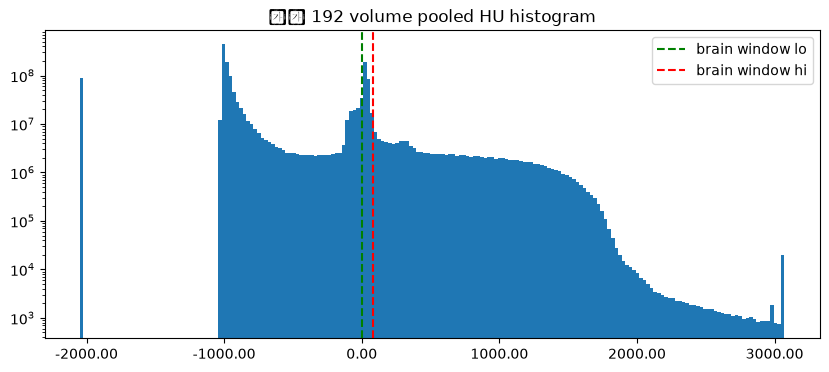

In [ ]:
bin_edges = np.round(np.linspace(-2048, 3072, 200), 2)
hist_total = np.zeros(len(bin_edges) - 1)

for key in common_keys:
    arr = sitk.GetArrayFromImage(sitk.ReadImage(str(image_map[key]))).astype(np.float32)
    counts, _ = np.histogram(arr.ravel(), bins=bin_edges)
    hist_total += counts

plt.figure(figsize=(10, 4))
plt.bar(bin_edges[:-1], hist_total, width=np.diff(bin_edges), align='edge')
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.yscale('log')
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
plt.legend()
plt.title('전체 192 volume pooled HU histogram')
plt.show()

### 3. Class

In [ ]:
slice_bleed_counter = Counter()   # 3.1용: 슬라이스당 동시출현 타입 개수
scan_bleed_counter  = Counter()   # 3.1용: 스캔당 동시출현 타입 개수
slice_type_counter  = Counter()   # 3.2용: 타입별 등장 슬라이스 수
scan_type_counter   = Counter()   # 3.2용: 타입별 등장 스캔 수

for key in common_keys:
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))
    scan_classes_present = set()

    for z in range(mask.shape[0]):
        classes_in_slice = set(np.unique(mask[z]).tolist()) - {0}
        slice_bleed_counter[len(classes_in_slice)] += 1
        for c in classes_in_slice:
            slice_type_counter[c] += 1
        scan_classes_present |= classes_in_slice

    scan_bleed_counter[len(scan_classes_present)] += 1
    for c in scan_classes_present:
        scan_type_counter[c] += 1

#### 3.1 Number of Bleed

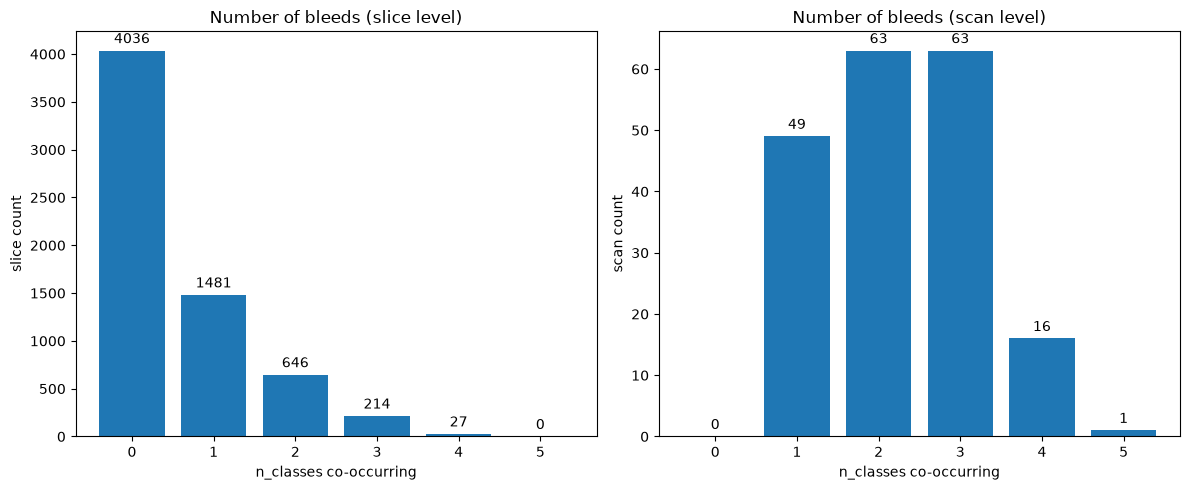

In [186]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

slice_x = list(range(6))
slice_y = [slice_bleed_counter.get(n, 0) for n in slice_x]
bars0 = axes[0].bar(slice_x, slice_y)
axes[0].set_title('Number of bleeds (slice level)')
axes[0].set_xlabel('n_classes co-occurring')
axes[0].set_ylabel('slice count')
axes[0].bar_label(bars0, padding=3)

scan_x = list(range(6))
scan_y = [scan_bleed_counter.get(n, 0) for n in scan_x]
bars1 = axes[1].bar(scan_x, scan_y)
axes[1].set_title('Number of bleeds (scan level)')
axes[1].set_xlabel('n_classes co-occurring')
axes[1].set_ylabel('scan count')
axes[1].bar_label(bars1, padding=3)

plt.tight_layout()
plt.show()

#### 3.2 Type of Bleed

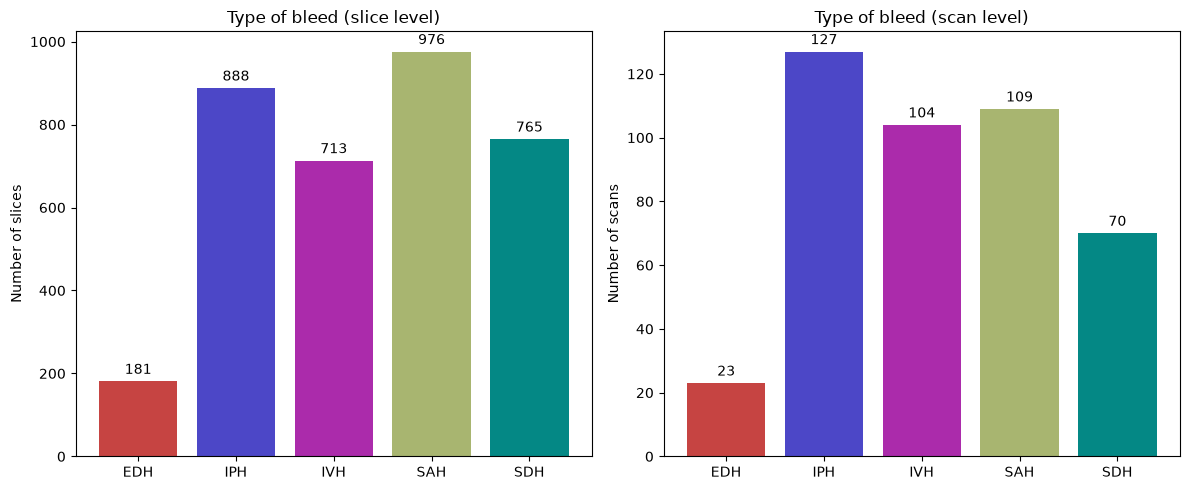

In [187]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels_slice = [class_names[c] for c in sorted(slice_type_counter)]
colors_slice = [np.array(class_colors[c]) / 255 for c in sorted(slice_type_counter)]
bars0 = axes[0].bar(labels_slice, [slice_type_counter[c] for c in sorted(slice_type_counter)], color=colors_slice)
axes[0].set_title('Type of bleed (slice level)')
axes[0].set_ylabel('Number of slices')
axes[0].bar_label(bars0, padding=3)

labels_scan = [class_names[c] for c in sorted(scan_type_counter)]
colors_scan = [np.array(class_colors[c]) / 255 for c in sorted(scan_type_counter)]
bars1 = axes[1].bar(labels_scan, [scan_type_counter[c] for c in sorted(scan_type_counter)], color=colors_scan)
axes[1].set_title('Type of bleed (scan level)')
axes[1].set_ylabel('Number of scans')
axes[1].bar_label(bars1, padding=3)

plt.tight_layout()
plt.show()

#### 3.3 Volume of Bleed

In [190]:
voxel_counter = Counter()

for key in common_keys:
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))
    vals, counts = np.unique(mask, return_counts=True)
    voxel_counter.update(dict(zip(vals.tolist(), counts.tolist())))

total_voxels = sum(voxel_counter.values())

rows = []
for c in range(1, 6):
    rows.append({
        'class_id': c,
        'name': class_names[c],
        'voxel_count': voxel_counter.get(c, 0),
        'voxel_ratio(%)': voxel_counter.get(c, 0) / total_voxels * 100,
    })

df_voxel = pd.DataFrame(rows)
display(df_voxel)

,class_id,name,voxel_count,voxel_ratio(%)
0,1,EDH,301856,0.02
1,2,IPH,2363791,0.14
2,3,IVH,709872,0.04
3,4,SAH,787323,0.05
4,5,SDH,1223801,0.07


In [ ]:
lesion_sizes_mm3 = {c: [] for c in range(1, 6)}
lesion_sizes_vox = {c: [] for c in range(1, 6)}

for key in common_keys:
    img_sitk = sitk.ReadImage(str(image_map[key]))
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))

    # SimpleITK spacing 순서: (x, y, z)
    # GetArrayFromImage 결과는 (z, y, x)이므로 곱셈 결과만 쓰면 순서 상관 없음
    spacing = np.array(img_sitk.GetSpacing(), dtype=np.float32)
    voxel_volume_mm3 = float(np.prod(spacing))

    for c in range(1, 6):
        class_mask = (mask == c)
        if not class_mask.any():
            continue

        labeled, n_components = ndimage.label(class_mask)
        sizes_vox = ndimage.sum(class_mask, labeled, index=range(1, n_components + 1))
        sizes_mm3 = sizes_vox * voxel_volume_mm3

        lesion_sizes_vox[c].extend(sizes_vox.tolist())
        lesion_sizes_mm3[c].extend(sizes_mm3.tolist())

rows = []
for c in range(1, 6):
    sizes = np.array(lesion_sizes_mm3[c], dtype=np.float32)

    if len(sizes) == 0:
        rows.append({
            'class_id': c,
            'name': class_names[c],
            'n_lesions': 0,
            'min_mm3': np.nan,
            'median_mm3': np.nan,
            'max_mm3': np.nan,
            'mean_mm3': np.nan,
        })
        continue

    rows.append({
        'class_id': c,
        'name': class_names[c],
        'n_lesions': len(sizes),
        'min_mm3': float(sizes.min()),
        'median_mm3': float(np.median(sizes)),
        'max_mm3': float(sizes.max()),
        'mean_mm3': float(sizes.mean()),
    })

df_lesion_size = pd.DataFrame(rows)
display(df_lesion_size)

,class_id,name,n_lesions,min_mm3,median_mm3,max_mm3,mean_mm3
0,1,EDH,43,1.03,718.27,133324.14,8033.50
1,2,IPH,304,0.60,891.81,194150.86,9102.14
2,3,IVH,345,0.60,353.57,65643.48,2506.14
3,4,SAH,1299,0.63,125.46,62655.96,718.89
4,5,SDH,391,0.62,69.98,150486.19,3720.97


#### 3.4 Class Weight

In [192]:
class_weights = {
    c: total_voxels / (voxel_counter.get(c, 1) * 5)
    for c in range(1, 6)
}
print("voxel 역빈도 기반 class weight:", class_weights)

voxel 역빈도 기반 class weight: {1: 1112.298696066999, 2: 142.04049139708206, 3: 472.9782766470575, 4: 426.4501801674789, 5: 274.3534571388649}


### 4. Visualization

In [196]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

targets = [4, 3, 2, 1]

# Collect representative scans
scan_rows = []
for key in common_keys:
    img_sitk = sitk.ReadImage(str(image_map[key]))
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))
    img_arr = sitk.GetArrayFromImage(img_sitk).astype(np.float32)

    # scan-level: number of distinct bleed types present in the whole volume
    scan_classes = sorted(set(np.unique(mask).tolist()) - {0})
    scan_n_classes = len(scan_classes)
    if scan_n_classes == 0:
        continue

    # representative slice within the scan: slice with the largest foreground area
    slice_rows = []
    for z in range(mask.shape[0]):
        slice_classes = sorted(set(np.unique(mask[z]).tolist()) - {0})
        if not slice_classes:
            continue
        fg_voxels = int((mask[z] > 0).sum())
        slice_rows.append((z, len(slice_classes), fg_voxels))

    if not slice_rows:
        continue

    best_z, best_slice_n_classes, best_fg_voxels = max(
        slice_rows, key=lambda x: (x[2], x[1])
    )

    scan_rows.append({
        "case": key,
        "patient_id": patient_id(key),
        "scan_n_classes": scan_n_classes,
        "scan_classes": scan_classes,
        "best_z": best_z,
        "best_slice_n_classes": best_slice_n_classes,
        "best_fg_voxels": best_fg_voxels,
    })

df_scan_vis = pd.DataFrame(scan_rows)

selected_rows = []
for t in targets:
    df_t = df_scan_vis[df_scan_vis["scan_n_classes"] == t].copy()
    if df_t.empty:
        print(f"[warn] scan-level bleed count {t}인 case가 없습니다.")
        continue
    selected_rows.append(df_t.sort_values(["best_fg_voxels", "case"], ascending=[False, True]).iloc[0])

if not selected_rows:
    raise ValueError("선택할 scan이 없습니다.")

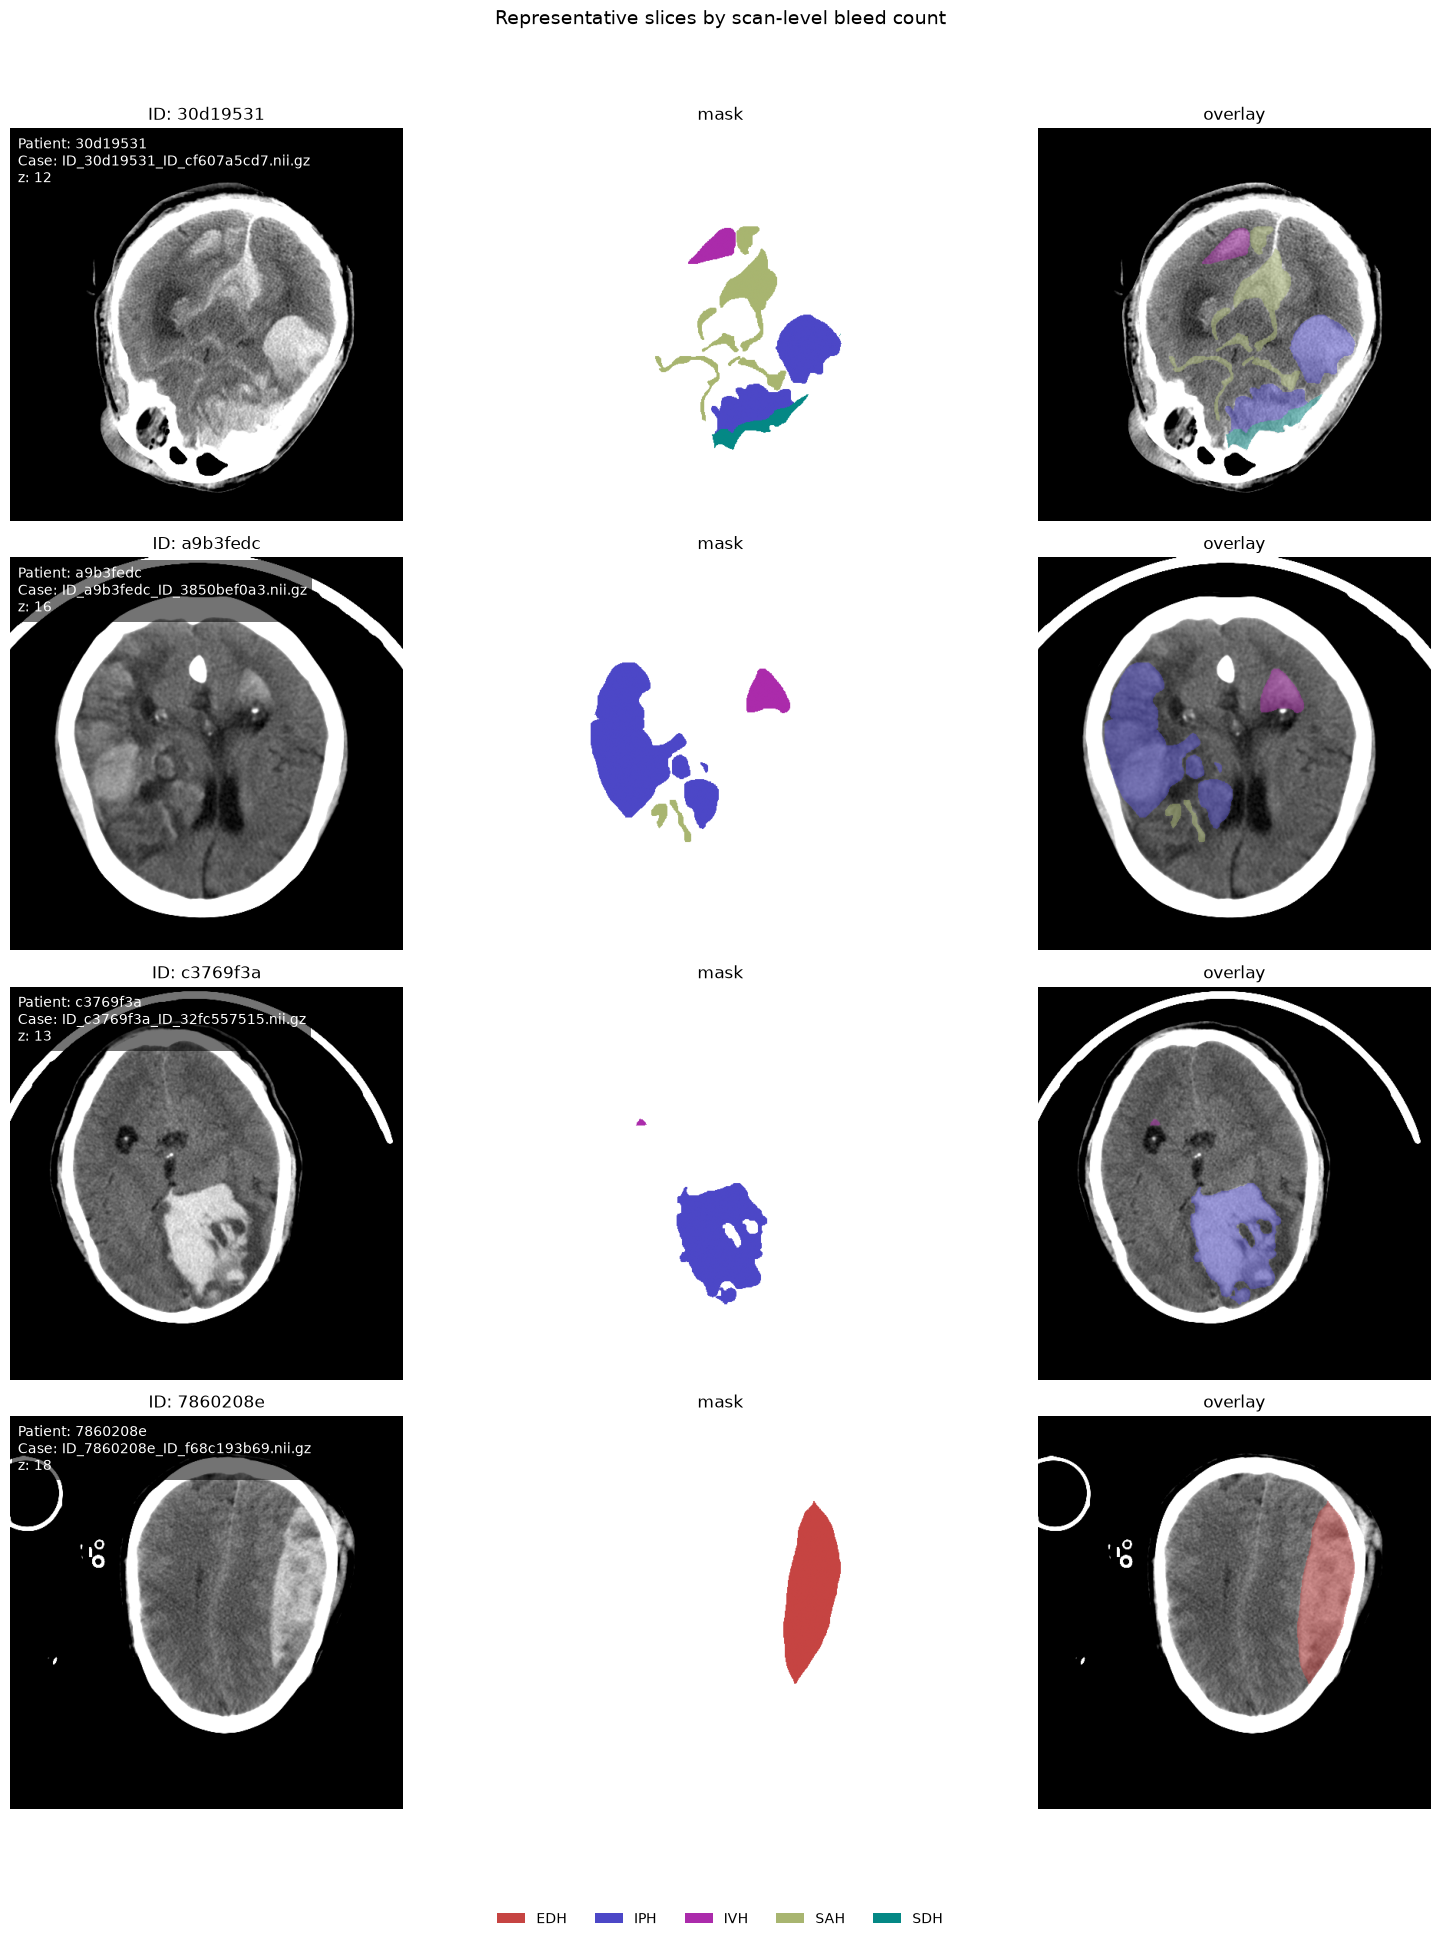

In [199]:
# Build custom colormap
n_classes = max(class_colors.keys()) + 1
colors_rgb = np.zeros((n_classes, 3))
for cls, rgb in class_colors.items():
    colors_rgb[cls] = np.array(rgb) / 255.0
custom_cmap = ListedColormap(colors_rgb)

fig, axes = plt.subplots(len(selected_rows), 3, figsize=(16, 4.8 * len(selected_rows)))
if len(selected_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, row in enumerate(selected_rows):
    key = row["case"]
    pid = row["patient_id"]
    z = int(row["best_z"])

    img_sitk = sitk.ReadImage(str(image_map[key]))
    mask = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))
    img_arr = sitk.GetArrayFromImage(img_sitk).astype(np.float32)

    image_slice = apply_window(img_arr[z])
    mask_slice = mask[z]
    mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
    mask_only_display = np.ma.masked_where(mask_slice == 0, mask_slice)

    axes[i, 0].imshow(image_slice, cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title(f"ID: {pid}")
    axes[i, 0].axis("off")
    axes[i, 0].text(
        0.02, 0.98,
        f"Patient: {pid}\nCase: {key}\nz: {z}",
        transform=axes[i, 0].transAxes,
        va="top",
        ha="left",
        fontsize=10,
        color="white",
        bbox=dict(facecolor="black", alpha=0.55, edgecolor="none", pad=4),
    )

    axes[i, 1].set_facecolor("black")
    axes[i, 1].imshow(mask_only_display, cmap=custom_cmap, vmin=0, vmax=5)
    axes[i, 1].set_title("mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(image_slice, cmap="gray", vmin=0, vmax=1)
    axes[i, 2].imshow(mask_overlay, cmap=custom_cmap, alpha=0.5, vmin=0, vmax=5)
    axes[i, 2].set_title("overlay")
    axes[i, 2].axis("off")

legend_handles = [
    Patch(facecolor=np.array(class_colors[c]) / 255.0, edgecolor="none", label=class_names[c])
    for c in sorted(class_colors)
]

fig.suptitle("Representative slices by scan-level bleed count", y=0.995, fontsize=14)
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

## 3. nnUNet Dataset

* 5cls dataset

In [ ]:
import json
import shutil
import random

# 1. 환자 단위로 어떤 클래스가 존재하는지 집계 (중복 환자의 여러 scan은 합쳐서 하나로 봄)
patient_classes = {}
for key in common_keys:
    pid = case_patient[key]
    m = sitk.GetArrayFromImage(sitk.ReadImage(str(mask_map[key])))
    classes = set(np.unique(m).tolist()) - {0}
    patient_classes.setdefault(pid, set())
    patient_classes[pid] |= classes # scan에서 나온 class를 더해서 갱신한 dict

patients = sorted(patient_classes.keys()) # key 즉, patient id를 정렬한 list
n_patients = len(patients)
val_ratio = 0.2

In [36]:
print(patient_classes)
print(patients)

{'0237f3c9': {2, 3}, '029ebbea': {2, 5}, '02b882cc': {2, 3, 4}, '02f779fb': {2, 3}, '041e6601': {1, 2, 5}, '0492041f': {2, 3}, '05331dc6': {2, 4, 5}, '07365cde': {2}, '089596a9': {2, 3}, '09b33fc4': {2, 3, 4, 5}, '0b10cbee': {1}, '0c3eef60': {2, 4, 5}, '0c6b97a9': {3, 4}, '10beb45f': {2}, '10c64d22': {2, 4, 5}, '14058625': {2, 4, 5}, '1653b22b': {2, 4}, '16ed917a': {2, 3}, '181aab15': {2, 3, 4, 5}, '18747540': {2, 3}, '1879071b': {2, 3, 4}, '196704db': {3}, '199b0a56': {2, 4}, '19d26713': {5}, '1cbe2853': {2}, '2334b45f': {2, 3, 4}, '253e809f': {2, 3, 4}, '268b38fe': {2, 4, 5}, '2872834a': {1}, '2931ca43': {4, 5}, '2949cdc6': {1, 4}, '2a42d0a0': {5}, '2db7ee14': {1, 4}, '2e21c3f3': {1, 5}, '30d19531': {2, 3, 4, 5}, '3343ddf2': {2, 3}, '338738e7': {2, 4}, '346de481': {1, 2, 5}, '39702b69': {2, 3, 4}, '39bdd84b': {3}, '39e94772': {5}, '3bda60be': {2, 3, 4}, '3be7cc35': {1, 4, 5}, '3dab46e7': {2, 3}, '3e481fc5': {1}, '41a55df8': {2, 3, 5}, '4681a956': {2, 3, 4}, '46cd34ad': {2, 4}, '47aa2

In [ ]:
# 2. random search로 class-balanced 80:20 split 탐색
#    (환자 수가 191명으로 적어서, 여러 후보 중 class별 val 비율이 0.2에 가장 가까운 걸 고르는 방식)
best_split = None
best_score = float('inf')
rng = random.Random(42)

for trial in range(2000):
    shuffled = patients[:]
    rng.shuffle(shuffled)
    n_val = round(n_patients * val_ratio)
    val_patients = set(shuffled[:n_val])
    train_patients = set(shuffled[n_val:])

    score = 0.0
    for c in range(1, 6):
        train_cnt = sum(1 for p in train_patients if c in patient_classes[p])
        val_cnt = sum(1 for p in val_patients if c in patient_classes[p])
        total_cnt = train_cnt + val_cnt
        if total_cnt == 0:
            continue
        score += (val_cnt / total_cnt - val_ratio) ** 2

    if score < best_score:
        best_score = score
        best_split = (sorted(train_patients), sorted(val_patients))

train_patients, val_patients = best_split
print(f"balance score: {best_score:.5f}")
print(f"train patients: {len(train_patients)}, val patients: {len(val_patients)}")

# 3. 환자 -> case 매핑으로 되돌리기 (같은 환자의 case는 항상 같은 split에)
train_keys = [k for k in common_keys if case_patient[k] in train_patients]
val_keys = [k for k in common_keys if case_patient[k] in val_patients]
print(f"train cases: {len(train_keys)}, val cases: {len(val_keys)}")

# 4. 검증: 클래스별 val 비율이 실제로 0.2 근처인지 확인
rows = []
for c in range(1, 6):
    train_cnt = sum(1 for p in train_patients if c in patient_classes[p])
    val_cnt = sum(1 for p in val_patients if c in patient_classes[p])
    rows.append({
        'class': class_names[c],
        'train_patients': train_cnt,
        'val_patients': val_cnt,
        'val_ratio': val_cnt / (train_cnt + val_cnt),
    })
display(pd.DataFrame(rows))

balance score: 0.00039
train patients: 153, val patients: 38
train cases: 154, val cases: 38


,class,train_patients,val_patients,val_ratio
0,EDH,18,4,0.18
1,IPH,101,26,0.20
2,IVH,83,21,0.20
3,SAH,87,21,0.19
4,SDH,56,14,0.20


In [ ]:
NNUNET_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet")
DATASET_ID = 1
DATASET_NAME = f"Dataset{DATASET_ID:03d}_BHSD"

DATASET_DIR = NNUNET_ROOT / "nnUNet_raw" / DATASET_NAME
imagesTr = DATASET_DIR / "imagesTr"
labelsTr = DATASET_DIR / "labelsTr"
imagesTs = DATASET_DIR / "imagesTs"
labelsTs = DATASET_DIR / "labelsTs"  # nnUNet 공식 스펙엔 없지만, 최종 평가용으로 우리가 따로 보관
for d in (imagesTr, labelsTr, imagesTs, labelsTs):
    d.mkdir(parents=True, exist_ok=True)

def case_id(filename: str) -> str:
    return filename.replace(".nii.gz", "")

# train_keys(80%) -> Tr, val_keys(20%, 이제 test로 씀) -> Ts
for key in train_keys:
    cid = case_id(key)
    shutil.copy2(image_map[key], imagesTr / f"{cid}_0000.nii.gz")
    shutil.copy2(mask_map[key], labelsTr / f"{cid}.nii.gz")

for key in val_keys:
    cid = case_id(key)
    shutil.copy2(image_map[key], imagesTs / f"{cid}_0000.nii.gz")
    shutil.copy2(mask_map[key], labelsTs / f"{cid}.nii.gz")  # 우리 전용 정답, nnUNet은 안 씀

dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {
        "background": 0,
        "epidural": 1,
        "intraparenchymal": 2,
        "intraventricular": 3,
        "subarachnoid": 4,
        "subdural": 5,
    },
    "numTraining": len(train_keys),   # Test는 numTraining에 안 들어감
    "file_ending": ".nii.gz",
}
with open(DATASET_DIR / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)

print(f"Train(Tr): {len(train_keys)}, Test(Ts): {len(val_keys)}")

Train(Tr): 154, Test(Ts): 38


* 1cls dataset

In [38]:
import shutil
import SimpleITK as sitk
import numpy as np
import json
from pathlib import Path

NNUNET_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet")
SRC_DATASET_DIR = NNUNET_ROOT / "nnUNet_raw" / "Dataset001_BHSD"
DST_DATASET_DIR = NNUNET_ROOT / "nnUNet_raw" / "Dataset002_BHSD_1cls"

src_imagesTr, src_labelsTr = SRC_DATASET_DIR / "imagesTr", SRC_DATASET_DIR / "labelsTr"
src_imagesTs, src_labelsTs = SRC_DATASET_DIR / "imagesTs", SRC_DATASET_DIR / "labelsTs"

dst_imagesTr = DST_DATASET_DIR / "imagesTr"
dst_labelsTr = DST_DATASET_DIR / "labelsTr"
dst_imagesTs = DST_DATASET_DIR / "imagesTs"
dst_labelsTs = DST_DATASET_DIR / "labelsTs"
for d in (dst_imagesTr, dst_labelsTr, dst_imagesTs, dst_labelsTs):
    d.mkdir(parents=True, exist_ok=True)

In [39]:
# mask 변환
def convert_to_1cls(src_path: Path, dst_path: Path):
    img = sitk.ReadImage(str(src_path))
    arr = sitk.GetArrayFromImage(img)          # 정수 라벨맵 (0,1,2,3,4,5)
    arr_1cls = (arr > 0).astype(np.uint8)       # 0이 아니면 전부 1
    out = sitk.GetImageFromArray(arr_1cls)
    out.CopyInformation(img)                    # spacing/origin/direction 반드시 유지
    sitk.WriteImage(out, str(dst_path))

In [40]:
# 이미지는 그대로 복사 (내용 안 바뀜, split도 동일하게 유지)
for src_dir, dst_dir in [(src_imagesTr, dst_imagesTr), (src_imagesTs, dst_imagesTs)]:
    for f in src_dir.glob("*.nii.gz"):
        shutil.copy2(f, dst_dir / f.name)

# 라벨은 변환해서 저장
for src_dir, dst_dir in [(src_labelsTr, dst_labelsTr), (src_labelsTs, dst_labelsTs)]:
    for f in src_dir.glob("*.nii.gz"):
        convert_to_1cls(f, dst_dir / f.name)

# dataset.json 작성 (클래스가 1개로 줄었으므로 labels 딕셔너리도 변경)
n_train = len(list(dst_imagesTr.glob("*.nii.gz")))
dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {"background": 0, "ich": 1},
    "numTraining": n_train,
    "file_ending": ".nii.gz",
}
with open(DST_DATASET_DIR / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=4)

print(f"Tr images: {len(list(dst_imagesTr.glob('*.nii.gz')))}, "
      f"Tr labels: {len(list(dst_labelsTr.glob('*.nii.gz')))}, "
      f"Ts images: {len(list(dst_imagesTs.glob('*.nii.gz')))}, "
      f"Ts labels: {len(list(dst_labelsTs.glob('*.nii.gz')))}")

Tr images: 154, Tr labels: 154, Ts images: 38, Ts labels: 38


In [ ]:
# 변환 확인
# 숫자


DATASET_1CLS_DIR = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_raw/Dataset002_BHSD_1cls")

patient_key = common_keys[0]
cid = patient_key.replace(".nii.gz", "")   # 확장자 먼저 제거

img_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(DATASET_1CLS_DIR / "imagesTr" / f"{cid}_0000.nii.gz")))
mask_arr = sitk.GetArrayFromImage(sitk.ReadImage(str(DATASET_1CLS_DIR / "labelsTr" / f"{cid}.nii.gz")))
print("마스크 고유값:", np.unique(mask_arr))

num_slices = 15
target_slice_img = img_arr[num_slices]
target_slice_mask = mask_arr[num_slices]

ys, xs = np.where(target_slice_mask > 0)

if len(xs) == 0:
    print(f"{num_slices}번 슬라이스에는 병변이 없습니다.")
else:
    margin = 10
    y0, y1 = max(ys.min() - margin, 0), min(ys.max() + margin, target_slice_mask.shape[0])
    x0, x1 = max(xs.min() - margin, 0), min(xs.max() + margin, target_slice_mask.shape[1])

    cropped_img = target_slice_img[y0:y1, x0:x1]
    cropped_mask = target_slice_mask[y0:y1, x0:x1]

    print("crop 영역 (y0:y1, x0:x1):", (y0, y1, x0, x1))
    print("crop된 이미지 배열:\n", cropped_img)
    print("\ncrop된 마스크 배열(0/1만 있어야 함):\n", cropped_mask)
    print("마스크 고유값:", np.unique(cropped_mask))  # [0, 1]만 나오면 변환 성공

마스크 고유값: [0 1]
crop 영역 (y0:y1, x0:x1): (np.int64(137), np.int64(259), np.int64(241), np.int64(321))
crop된 이미지 배열:
 [[33. 28. 31. ... 31. 34. 34.]
 [33. 30. 31. ... 36. 36. 36.]
 [37. 35. 35. ... 38. 35. 31.]
 ...
 [12. 18. 24. ... 44. 43. 41.]
 [ 7. 13. 22. ... 42. 43. 44.]
 [ 6. 13. 22. ... 40. 41. 40.]]

crop된 마스크 배열(0/1만 있어야 함):
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
마스크 고유값: [0 1]


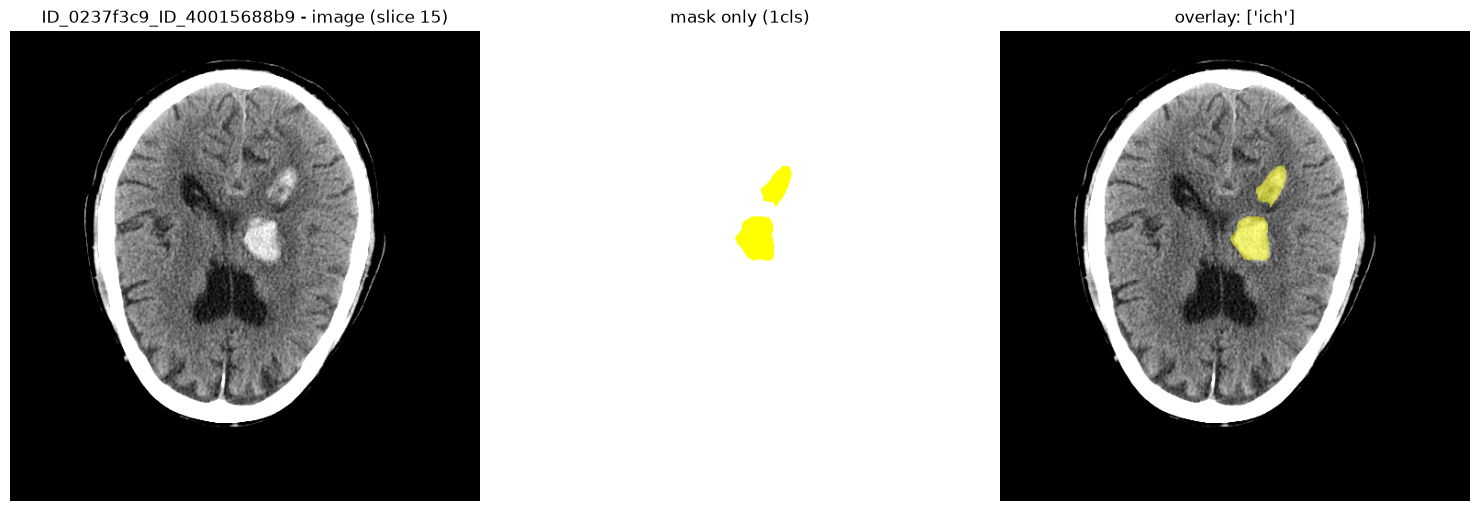

In [56]:
fg_voxels_per_slice = (mask_arr > 0).sum(axis=(1, 2))
best_z = int(np.argmax(fg_voxels_per_slice))

windowed_slice = apply_window(img_arr[best_z])
mask_slice = mask_arr[best_z]
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'{cid} - image (slice {best_z})')
axes[0].axis('off')

n_classes = max(class_colors_1cls.keys()) + 1   # 1 + 1 = 2 (0, 1)
colors_rgb = np.zeros((n_classes, 3))
for cls, rgb in class_colors_1cls.items():
    colors_rgb[cls] = np.array(rgb) / 255
custom_cmap = ListedColormap(colors_rgb)

mask_only_display = np.ma.masked_where(mask_slice == 0, mask_slice)
axes[1].set_facecolor('black')
axes[1].imshow(mask_only_display, cmap=custom_cmap, vmin=0, vmax=1)
axes[1].set_title('mask only (1cls)')
axes[1].axis('off')

axes[2].imshow(windowed_slice, cmap='gray', vmin=0, vmax=1)
axes[2].imshow(mask_overlay, cmap=custom_cmap, alpha=0.5, vmin=0, vmax=1)
present = [class_names_1cls[c] for c in np.unique(mask_slice) if c != 0]
axes[2].set_title(f'overlay: {present}')
axes[2].axis('off')
plt.tight_layout()
plt.show()